# 🤖 Football Match Prediction Model Training

This notebook focuses on the training, evaluation, and comparison of machine learning models designed to predict football match outcomes using engineered historical performance features.

The modeling process aims to identify the most effective predictive approaches while maintaining interpretability, robustness, and analytical consistency.

---

## 📌 Main Objectives

- Train predictive machine learning models
- Evaluate classification performance
- Compare different modeling approaches
- Analyze feature importance and predictive behavior
- Build a robust football analytics prediction pipeline

---


In [1]:
# 🎨 Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

sns.set_theme(style="whitegrid", palette="viridis")


# ============================================
# 🌍 FIFA World Cup Project
# 🤖 Match Prediction Model Training
# ============================================

---

## 🗂️ Dataset Preparation

Preparing datasets for machine learning training and evaluation.

## 🤖 Model Training

Training machine learning algorithms for football match prediction.

## 📈 Model Evaluation

Assessing predictive performance using classification metrics.

## 📊 Visual Analytics

Visualizing model performance and analytical insights.

In [2]:
# ============================================
# 📚 Import Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
# ============================================
# 📥 Load Dataset
# ============================================

team_df = pd.read_csv(
    "../data/processed/advanced_features.csv"
)

team_df.head()

,date,team,opponent,goals_scored,goals_conceded,goal_difference,is_home,match_points,avg_points_last_5,avg_goals_scored_last_5,avg_goals_conceded_last_5,avg_goal_diff_last_5,win,win_streak,clean_sheet,clean_sheets_last_5,momentum_score
0,1872-11-30,Scotland,England,0.0,0.0,0.0,1,1,NaN,NaN,NaN,NaN,0,NaN,1,NaN,NaN
1,1872-11-30,England,Scotland,0.0,0.0,0.0,0,1,NaN,NaN,NaN,NaN,0,NaN,1,NaN,NaN
2,1873-03-08,Scotland,England,2.0,4.0,-2.0,0,0,1.0,0.0,0.0,0.0,0,0.0,0,1.0,5.000000e-01
3,1873-03-08,England,Scotland,4.0,2.0,2.0,1,3,1.0,0.0,0.0,0.0,1,0.0,0,1.0,5.000000e-01
4,1874-03-07,Scotland,England,2.0,1.0,1.0,1,3,0.5,1.0,2.0,-1.0,1,0.0,0,1.0,2.775558e-17


In [4]:
# 🇩🇪 Data Standardization: Germany Unification

# Automatically detect dataframe variables
possible_dfs = [
    "df",
    "matches",
    "results",
    "world_cup",
    "team_metrics",
    "data"
]

for df_name in possible_dfs:

    if df_name in globals():

        dataframe = globals()[df_name]

        country_columns = [
            col for col in dataframe.columns
            if any(keyword in col.lower()
                   for keyword in ["team", "country", "winner", "home", "away"])
        ]

        for col in country_columns:
            dataframe[col] = dataframe[col].replace("West Germany", "Germany")

        print(f"✅ Germany standardization applied to: {df_name}")


## ⚙️ Feature Selection

Defining predictive variables and target labels.

In [5]:
# ============================================
# 🏠 Home Team Dataset
# ============================================

home_features = team_df[
    team_df["is_home"] == 1
].copy()

away_features = team_df[
    team_df["is_home"] == 0
].copy()

In [6]:
# ============================================
# 🔄 Rename Columns
# ============================================

home_features = home_features.rename(columns={

    "team": "home_team",

    "avg_points_last_5":
        "home_avg_points_last_5",

    "avg_goals_scored_last_5":
        "home_avg_goals_scored_last_5",

    "avg_goals_conceded_last_5":
        "home_avg_goals_conceded_last_5",

    "avg_goal_diff_last_5":
        "home_avg_goal_diff_last_5",

    "win_streak":
        "home_win_streak",

    "clean_sheets_last_5":
        "home_clean_sheets_last_5",

    "momentum_score":
        "home_momentum_score"
})

In [7]:
away_features = away_features.rename(columns={

    "team": "away_team",

    "avg_points_last_5":
        "away_avg_points_last_5",

    "avg_goals_scored_last_5":
        "away_avg_goals_scored_last_5",

    "avg_goals_conceded_last_5":
        "away_avg_goals_conceded_last_5",

    "avg_goal_diff_last_5":
        "away_avg_goal_diff_last_5",

    "win_streak":
        "away_win_streak",

    "clean_sheets_last_5":
        "away_clean_sheets_last_5",

    "momentum_score":
        "away_momentum_score"
})

In [8]:
# ============================================
# 🔗 Merge Home and Away Features
# ============================================

match_df = pd.merge(

    home_features,

    away_features,

    on="date",

    suffixes=("_home", "_away")
)

In [9]:
# ============================================
# 🎯 Target Variable
# ============================================

match_df["target"] = np.where(

    match_df["goal_difference_home"] > 0,
    "Home Win",

    np.where(
        match_df["goal_difference_home"] < 0,
        "Away Win",
        "Draw"
    )
)

match_df["target"].value_counts()

target
Home Win    276322
Away Win    165326
Draw        133153
Name: count, dtype: int64

In [10]:
# ============================================
# 🔗 Build Match-Level Dataset
# ============================================

home_features = team_df[team_df["is_home"] == 1].copy()
away_features = team_df[team_df["is_home"] == 0].copy()

home_cols = [
    "date", "team", "opponent",
    "goals_scored", "goals_conceded", "goal_difference",
    "avg_points_last_5", "avg_goals_scored_last_5",
    "avg_goals_conceded_last_5", "avg_goal_diff_last_5",
    "win_streak", "clean_sheets_last_5", "momentum_score"
]

away_cols = home_cols.copy()

home_features = home_features[home_cols].rename(columns={
    "team": "home_team",
    "opponent": "away_team",
    "goals_scored": "home_goals",
    "goals_conceded": "home_goals_conceded",
    "goal_difference": "home_goal_difference",
    "avg_points_last_5": "home_avg_points_last_5",
    "avg_goals_scored_last_5": "home_avg_goals_scored_last_5",
    "avg_goals_conceded_last_5": "home_avg_goals_conceded_last_5",
    "avg_goal_diff_last_5": "home_avg_goal_diff_last_5",
    "win_streak": "home_win_streak",
    "clean_sheets_last_5": "home_clean_sheets_last_5",
    "momentum_score": "home_momentum_score"
})

away_features = away_features[away_cols].rename(columns={
    "team": "away_team",
    "opponent": "home_team",
    "goals_scored": "away_goals",
    "goals_conceded": "away_goals_conceded",
    "goal_difference": "away_goal_difference",
    "avg_points_last_5": "away_avg_points_last_5",
    "avg_goals_scored_last_5": "away_avg_goals_scored_last_5",
    "avg_goals_conceded_last_5": "away_avg_goals_conceded_last_5",
    "avg_goal_diff_last_5": "away_avg_goal_diff_last_5",
    "win_streak": "away_win_streak",
    "clean_sheets_last_5": "away_clean_sheets_last_5",
    "momentum_score": "away_momentum_score"
})

match_df = pd.merge(
    home_features,
    away_features,
    on=["date", "home_team", "away_team"],
    how="inner"
)

match_df.head()

,date,home_team,away_team,home_goals,home_goals_conceded,home_goal_difference,home_avg_points_last_5,home_avg_goals_scored_last_5,home_avg_goals_conceded_last_5,home_avg_goal_diff_last_5,home_win_streak,home_clean_sheets_last_5,home_momentum_score,away_goals,away_goals_conceded,away_goal_difference,away_avg_points_last_5,away_avg_goals_scored_last_5,away_avg_goals_conceded_last_5,away_avg_goal_diff_last_5,away_win_streak,away_clean_sheets_last_5,away_momentum_score
0,1872-11-30,Scotland,England,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,2.0,1.000000,0.000000,0.000000,0.000000,0.0,1.0,5.000000e-01,2.0,4.0,-2.0,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.500000
2,1874-03-07,Scotland,England,2.0,1.0,1.0,0.500000,1.000000,2.000000,-1.000000,0.0,1.0,2.775558e-17,1.0,2.0,-1.0,2.000000,2.000000,1.000000,1.000000,1.0,1.0,1.400000
3,1875-03-06,England,Scotland,2.0,2.0,0.0,1.333333,1.666667,1.333333,0.333333,1.0,1.0,9.333333e-01,2.0,2.0,0.0,1.333333,1.333333,1.666667,-0.333333,1.0,1.0,0.733333
4,1876-03-04,Scotland,England,3.0,0.0,3.0,1.250000,1.500000,1.750000,-0.250000,1.0,1.0,7.250000e-01,0.0,3.0,-3.0,1.250000,1.750000,1.500000,0.250000,1.0,1.0,0.875000


In [11]:
# ============================================
# 🎯 Target Variable
# ============================================

match_df["target"] = np.where(
    match_df["home_goals"] > match_df["away_goals"],
    "Home Win",
    np.where(
        match_df["home_goals"] < match_df["away_goals"],
        "Away Win",
        "Draw"
    )
)

match_df["target"].value_counts()

target
Home Win    23754
Away Win    13665
Draw        11172
Name: count, dtype: int64

In [12]:
# ============================================
# ⚙️ Feature Selection
# ============================================

features = [
    "home_avg_points_last_5",
    "away_avg_points_last_5",
    "home_avg_goals_scored_last_5",
    "away_avg_goals_scored_last_5",
    "home_avg_goals_conceded_last_5",
    "away_avg_goals_conceded_last_5",
    "home_avg_goal_diff_last_5",
    "away_avg_goal_diff_last_5",
    "home_win_streak",
    "away_win_streak",
    "home_clean_sheets_last_5",
    "away_clean_sheets_last_5",
    "home_momentum_score",
    "away_momentum_score"
]

X = match_df[features].fillna(0)
y = match_df["target"]

In [13]:
# ============================================
# 🔤 Encode Target
# ============================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Away Win' 'Draw' 'Home Win']


In [14]:
# ============================================
# ✂️ Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (38872, 14)
Test Shape: (9719, 14)


## 🔮 Prediction Analysis

Exploring prediction behavior and probability outputs.

In [15]:
# ============================================
# 🤖 Logistic Regression
# ============================================

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

log_predictions = (
    log_model.predict(X_test)
)

log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

print(
    f"Logistic Regression Accuracy: {log_accuracy:.4f}"
)

Logistic Regression Accuracy: 0.5255


In [16]:
# ============================================
# 🌲 Random Forest
# ============================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = (
    rf_model.predict(X_test)
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    f"Random Forest Accuracy: {rf_accuracy:.4f}"
)

Random Forest Accuracy: 0.5270


In [17]:
# ============================================
# 📊 Model Comparison
# ============================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.525466
1,Random Forest,0.527009


## 🌟 Feature Importance Analysis

Identifying the most influential predictive features.

In [18]:
# ============================================
# 🌟 Feature Importance
# ============================================

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance":
        rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
6,home_avg_goal_diff_last_5,0.139008
7,away_avg_goal_diff_last_5,0.132986
12,home_momentum_score,0.129757
13,away_momentum_score,0.126784
5,away_avg_goals_conceded_last_5,0.078863
4,home_avg_goals_conceded_last_5,0.073919
1,away_avg_points_last_5,0.058463
0,home_avg_points_last_5,0.058215
2,home_avg_goals_scored_last_5,0.053806
3,away_avg_goals_scored_last_5,0.051629


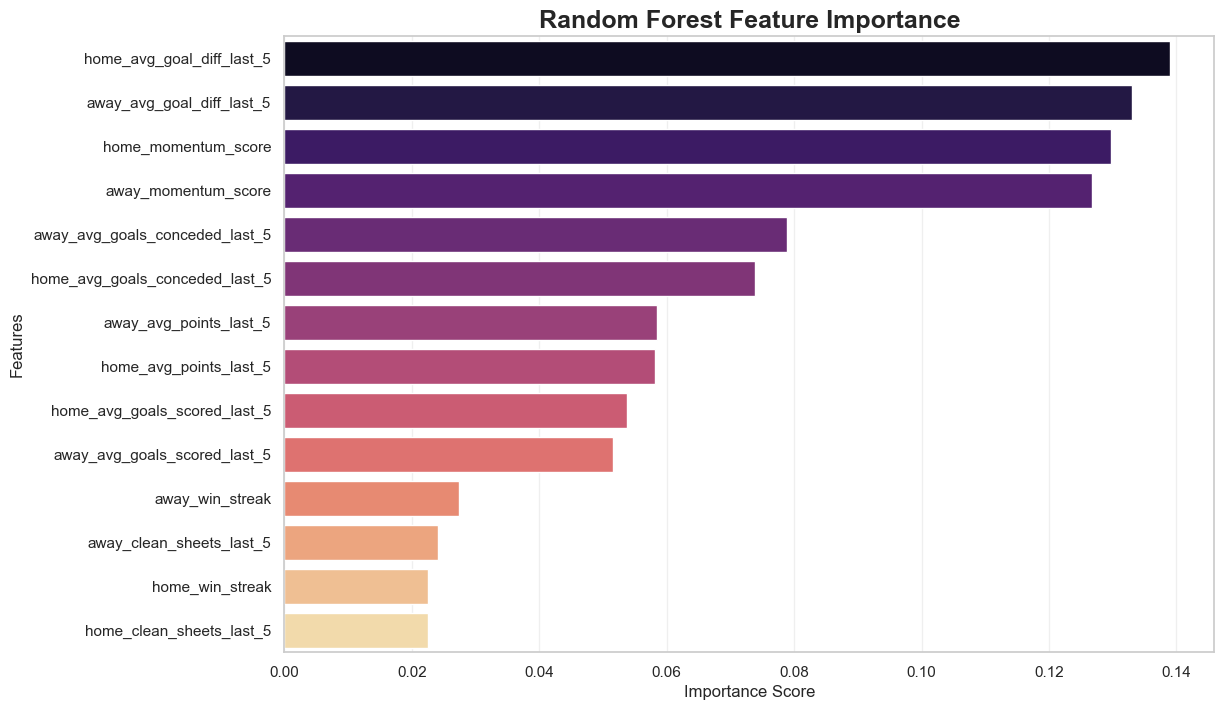

<Figure size 1200x600 with 0 Axes>

In [19]:
# ============================================
# 📈 Feature Importance Visualization
# ============================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df,

    x="Importance",

    y="Feature",

    palette="magma"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=18,
    weight="bold"
)

plt.xlabel(
    "Importance Score",
    fontsize=12
)

plt.ylabel(
    "Features",
    fontsize=12
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

plt.tight_layout()

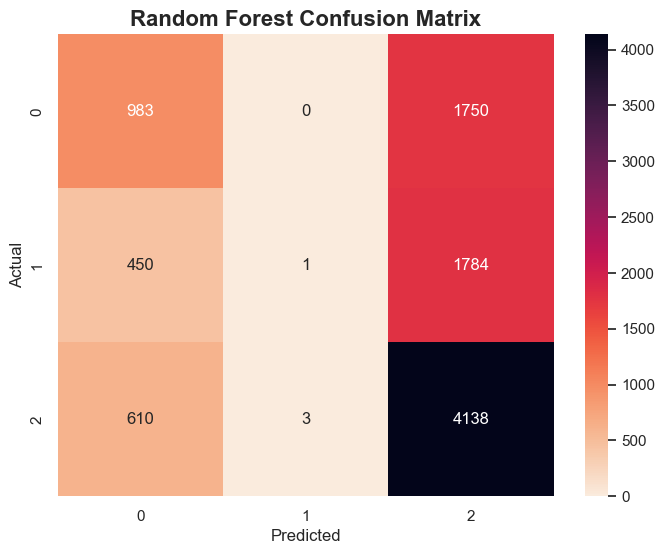

<Figure size 1200x600 with 0 Axes>

In [20]:
# ============================================
# 📉 Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="rocket_r"
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.tight_layout()

In [21]:
# ============================================
# 📋 Classification Report
# ============================================

print(

    classification_report(
        y_test,
        rf_predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

    Away Win       0.48      0.36      0.41      2733
        Draw       0.25      0.00      0.00      2235
    Home Win       0.54      0.87      0.67      4751

    accuracy                           0.53      9719
   macro avg       0.42      0.41      0.36      9719
weighted avg       0.46      0.53      0.44      9719



In [22]:
# ============================================
# 💾 Save Final Match Dataset
# ============================================

match_df.to_csv(
    "../data/processed/final_match_dataset.csv",
    index=False
)

print(
    "✅ Final match dataset saved successfully."
)

✅ Final match dataset saved successfully.
